In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Dense

In [2]:
df = pd.read_csv('AirQuality.csv', sep=';', low_memory=False)

In [3]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [4]:
df.dropna(axis=1, how='all', inplace=True)

In [5]:
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(',', '.').str.strip()
    try:
        df[col] = df[col].astype(float)
    except:
        pass

In [6]:
df.replace(-200, np.nan, inplace=True)
df.drop(columns=['Date', 'Time'], errors='ignore', inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')

In [7]:
# Define target and feature columns
pollutants = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
excluded_cols = ['Date', 'Time'] + pollutants
features = [col for col in df.columns if col not in excluded_cols]

In [8]:
# Drop NaNs
df = df.dropna(subset=features + pollutants)

In [9]:
# Scale features and targets
X = df[features].values
y = df[pollutants].values
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [10]:
# Create sequences
TIME_STEPS = 10
def create_sequences(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled)

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

In [12]:
# Build model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    LSTM(64),
    Dropout(0.2),
    Dense(len(pollutants))
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

C:\Users\Jahnavi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Train
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0930 - mae: 0.2356 - val_loss: 0.0380 - val_mae: 0.1581
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0373 - mae: 0.1540 - val_loss: 0.0309 - val_mae: 0.1259
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0311 - mae: 0.1356 - val_loss: 0.0287 - val_mae: 0.1291
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0296 - mae: 0.1335 - val_loss: 0.0269 - val_mae: 0.1200
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0265 - mae: 0.1257 - val_loss: 0.0261 - val_mae: 0.1242
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0259 - mae: 0.1265 - val_loss: 0.0235 - val_mae: 0.1131
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0251 - mae: 0.1215 - val_loss: 0.0213 - val_mae: 0.1047
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0211 - mae: 0.1112 - val_loss: 0.0186 - val_mae: 0.1000
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.020

In [14]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test MAE:", mae)
Accuracy= (1-mae)*100
print("Accuracy of the Model:", Accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0157 - mae: 0.0908
Test Loss: 0.015052582137286663
Test MAE: 0.08998044580221176
Accuracy of the Model: 91.00195541977882


In [15]:
# Predict on test set
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


In [16]:
# Plot predicted vs actual for each pollutant
pollutant_names = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
num_pollutants = len(pollutant_names)

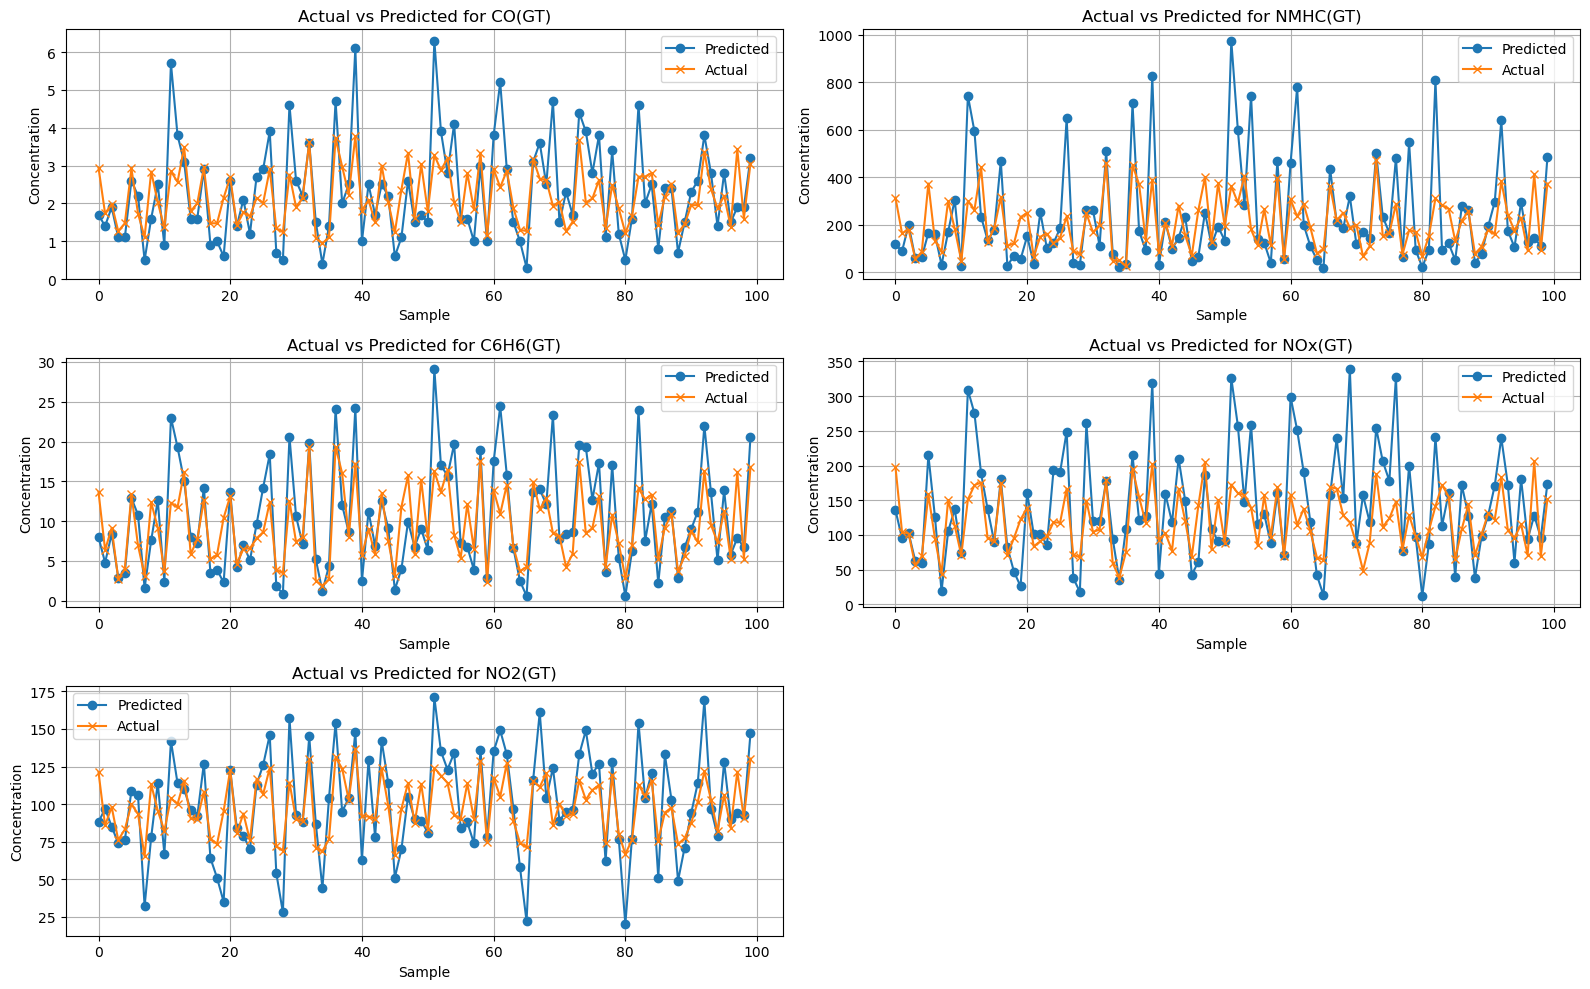

In [17]:
plt.figure(figsize=(16, 10))
for i in range(num_pollutants):
    plt.subplot(3, 2, i + 1)
    plt.plot(y_true[:100, i], label='Predicted', marker='o')
    plt.plot(y_pred[:100, i], label='Actual', marker='x')
    plt.title(f'Actual vs Predicted for {pollutant_names[i]}')
    plt.xlabel('Sample')
    plt.ylabel('Concentration')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Compute R² score for each pollutant
pollutant_names = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
for i, name in enumerate(pollutant_names):
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    print(f"R² Score for {name}: {r2:.4f}")

# Optional: Mean R² score (overall accuracy indicator)
mean_r2 = r2_score(y_true, y_pred)
print(f"\nOverall R² Score: {mean_r2:.4f}")

R² Score for CO(GT): 0.5068
R² Score for NMHC(GT): 0.4128
R² Score for C6H6(GT): 0.5670
R² Score for NOx(GT): 0.3929
R² Score for NO2(GT): 0.5654

Overall R² Score: 0.4890


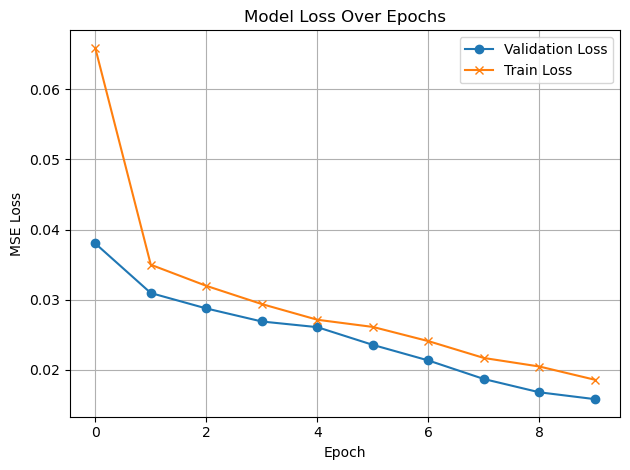

In [19]:
# Plot loss
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.plot(history.history['loss'], label='Train Loss', marker= 'x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()